In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib

plt.style.use('default')
pd.set_option('display.max_columns', None)

In [2]:
RAW_PATH = '../dataset/IMS_Data_200725-200726.csv'

PROCESSED_DIR = Path('../dataset/TCN processed')
ARTIFACT_DIR = Path('./artifacts')

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Raw path:', Path(RAW_PATH).resolve())

Raw path: D:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\dataset\IMS_Data_200725-200726.csv


In [3]:
df = pd.read_csv(RAW_PATH)

print('Shape awal:', df.shape)
df.head()

Shape awal: (1200, 8)


,Source,TagName,DateTime,State,Value,Unit,Quality,QualityStatus
0,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/20/2025 12:00:00.000 am,NaN,288.275,NaN,192,Good
1,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/20/2025 12:04:08.431 am,NaN,287.925,NaN,192,Good
2,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 3:55:25.663 am,NaN,345.527,NaN,192,Good
3,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 3:59:25.666 am,NaN,345.241,NaN,192,Good
4,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 4:00:25.733 am,NaN,345.244,NaN,192,Good


In [4]:
df = df[df['QualityStatus'] == 'Good'].copy()

print('Shape setelah filter quality:', df.shape)

Shape setelah filter quality: (1177, 8)


In [5]:
df = df[['DateTime', 'Value']].copy()
df.columns = ['timestamp', 'pressure']

df.head()

,timestamp,pressure
0,7/20/2025 12:00:00.000 am,288.275
1,7/20/2025 12:04:08.431 am,287.925
2,7/21/2025 3:55:25.663 am,345.527
3,7/21/2025 3:59:25.666 am,345.241
4,7/21/2025 4:00:25.733 am,345.244


In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['pressure'] = pd.to_numeric(df['pressure'], errors='coerce')

df = df.dropna()

print(df.dtypes)

timestamp    datetime64[ns]
pressure            float64
dtype: object


C:\Users\Zepunnn\AppData\Local\Temp\ipykernel_28180\3497870531.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


In [7]:
df = df.sort_values('timestamp').reset_index(drop=True)

print('Data awal :', df['timestamp'].min())
print('Data akhir:', df['timestamp'].max())

Data awal : 2025-07-20 00:00:00
Data akhir: 2026-07-20 08:34:16


In [8]:
INVALID_START = pd.Timestamp('2025-08-01 00:00:00')
INVALID_END   = pd.Timestamp('2026-04-30 23:59:59')

print('Periode tidak valid:')
print(INVALID_START, '->', INVALID_END)

Periode tidak valid:
2025-08-01 00:00:00 -> 2026-04-30 23:59:59


In [9]:
# sebelum periode invalid
segment_a = df[df['timestamp'] < INVALID_START].copy()

# setelah periode invalid
segment_b = df[df['timestamp'] > INVALID_END].copy()

print('Segmen A:', segment_a.shape)
print('Segmen B:', segment_b.shape)

Segmen A: (42, 2)
Segmen B: (266, 2)


In [10]:
def process_segment(seg, freq='1min', max_gap=30):
    seg = seg.copy()

    # set index
    seg = seg.set_index('timestamp')

    # resample ke 1 menit
    seg = seg.resample(freq).mean()

    # interpolasi hanya gap kecil
    seg['pressure'] = seg['pressure'].interpolate(
        method='time',
        limit=max_gap
    )

    # buang sisa NaN
    seg = seg.dropna()

    return seg

In [11]:
seg_a = process_segment(segment_a)
seg_b = process_segment(segment_b)

print('Seg A processed:', seg_a.shape)
print('Seg B processed:', seg_b.shape)

Seg A processed: (792, 1)
Seg B processed: (5306, 1)


In [12]:
df_final = pd.concat([seg_a, seg_b]).sort_index()

print('Final shape:', df_final.shape)
print(df_final.head())

Final shape: (6098, 1)
                     pressure
timestamp                    
2025-07-20 00:00:00  288.2750
2025-07-20 00:01:00  288.1875
2025-07-20 00:02:00  288.1000
2025-07-20 00:03:00  288.0125
2025-07-20 00:04:00  287.9250


In [13]:
mask_invalid = (
    (df_final.index >= INVALID_START) &
    (df_final.index <= INVALID_END)
)

print('Jumlah data invalid tersisa:', mask_invalid.sum())

Jumlah data invalid tersisa: 0


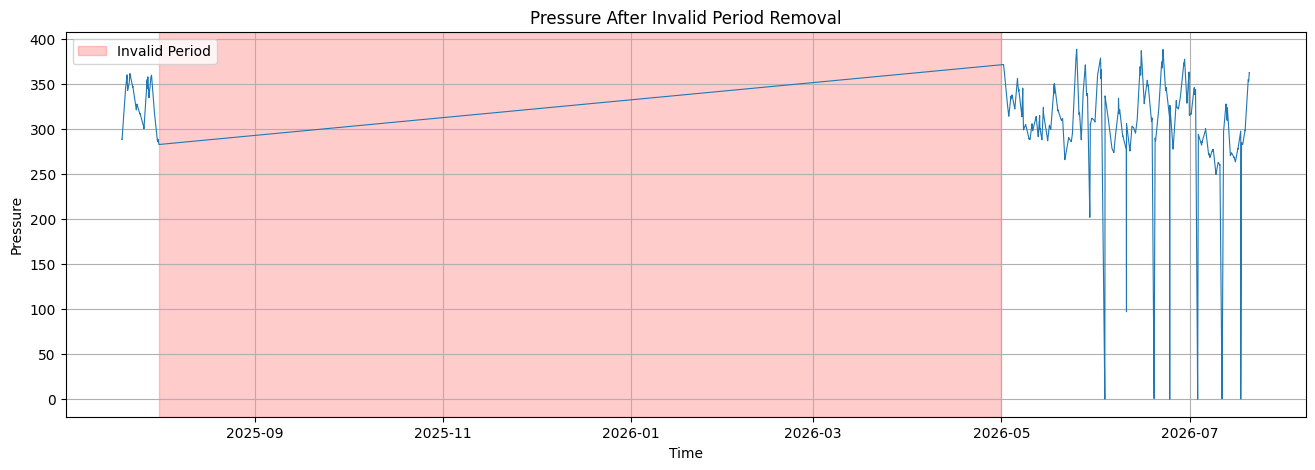

In [14]:
plt.figure(figsize=(16,5))

plt.plot(df_final.index, df_final['pressure'], linewidth=0.8)

plt.axvspan(
    INVALID_START,
    INVALID_END,
    color='red',
    alpha=0.2,
    label='Invalid Period'
)

plt.title('Pressure After Invalid Period Removal')
plt.xlabel('Time')
plt.ylabel('Pressure')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
TRAIN_END = pd.Timestamp('2026-06-30 23:59:59')
JULY_START = pd.Timestamp('2026-07-01 00:00:00')
JULY_END   = pd.Timestamp('2026-07-31 23:59:59')

print('Train sampai:', TRAIN_END)
print('Juli 2026 untuk evaluasi:', JULY_START, '->', JULY_END)

Train sampai: 2026-06-30 23:59:59
Juli 2026 untuk evaluasi: 2026-07-01 00:00:00 -> 2026-07-31 23:59:59


In [16]:
# training
train_df = df_final[df_final.index <= TRAIN_END].copy()

# evaluasi Juli 2026
eval_df = df_final[
    (df_final.index >= JULY_START) &
    (df_final.index <= JULY_END)
].copy()

print('Train shape:', train_df.shape)
print('Eval shape :', eval_df.shape)

Train shape: (4775, 1)
Eval shape : (1323, 1)


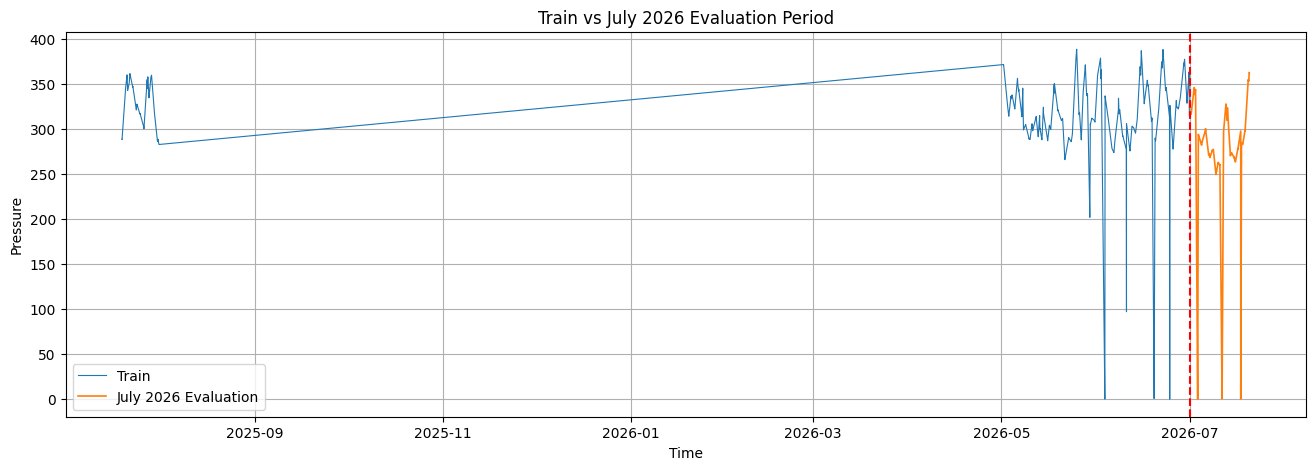

In [17]:
plt.figure(figsize=(16,5))

plt.plot(train_df.index, train_df['pressure'],
         label='Train', linewidth=0.8)

plt.plot(eval_df.index, eval_df['pressure'],
         label='July 2026 Evaluation', linewidth=1.2)

plt.axvline(TRAIN_END, color='red', linestyle='--')

plt.title('Train vs July 2026 Evaluation Period')
plt.xlabel('Time')
plt.ylabel('Pressure')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df[['pressure']])
eval_scaled  = scaler.transform(eval_df[['pressure']])

print('Train scaled:', train_scaled.shape)
print('Eval scaled :', eval_scaled.shape)

Train scaled: (4775, 1)
Eval scaled : (1323, 1)


In [19]:
print('Train scaled mean:', train_scaled.mean())
print('Train scaled std :', train_scaled.std())

Train scaled mean: -9.166373303208831e-16
Train scaled std : 1.0


In [20]:
train_timestamps = pd.DataFrame({
    'timestamp': train_df.index
})

eval_timestamps = pd.DataFrame({
    'timestamp': eval_df.index
})

train_timestamps.head()

,timestamp
0,2025-07-20 00:00:00
1,2025-07-20 00:01:00
2,2025-07-20 00:02:00
3,2025-07-20 00:03:00
4,2025-07-20 00:04:00


In [21]:
# numpy arrays
np.save(PROCESSED_DIR / 'train.npy', train_scaled)
np.save(PROCESSED_DIR / 'eval.npy', eval_scaled)

# timestamps
train_timestamps.to_csv(
    PROCESSED_DIR / 'train_timestamps.csv',
    index=False
)

eval_timestamps.to_csv(
    PROCESSED_DIR / 'eval_timestamps.csv',
    index=False
)

# scaler
joblib.dump(scaler, PROCESSED_DIR / 'scaler.pkl')

print('Saved:')
print('- train.npy')
print('- eval.npy')
print('- train_timestamps.csv')
print('- eval_timestamps.csv')
print('- scaler.pkl')

Saved:
- train.npy
- eval.npy
- train_timestamps.csv
- eval_timestamps.csv
- scaler.pkl


In [22]:
print('Processed files:')
for f in sorted(PROCESSED_DIR.glob('*')):
    print(f.name)

Processed files:
eval.npy
eval_timestamps.csv
scaler.pkl
train.npy
train_timestamps.csv


In [23]:
summary = pd.DataFrame({
    'Item': [
        'Raw data',
        'Valid data after cleaning',
        'Train data (<= Jun 2026)',
        'July 2026 evaluation data',
        'Resample frequency',
        'Interpolation limit',
        'Scaling method'
    ],
    'Value': [
        len(df),
        len(df_final),
        len(train_df),
        len(eval_df),
        '1 minute',
        '30 minutes',
        'StandardScaler'
    ]
})

summary

,Item,Value
0,Raw data,1177
1,Valid data after cleaning,6098
2,Train data (<= Jun 2026),4775
3,July 2026 evaluation data,1323
4,Resample frequency,1 minute
5,Interpolation limit,30 minutes
6,Scaling method,StandardScaler
